<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/bifurcation_diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

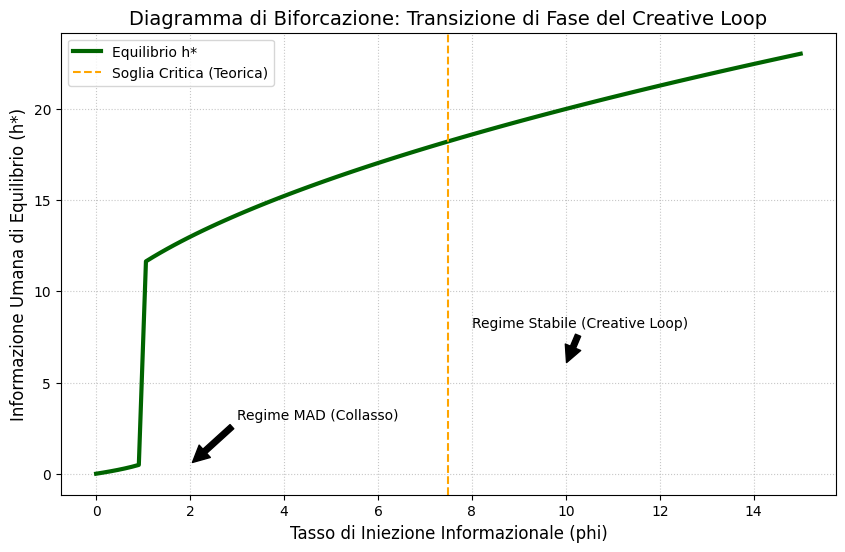

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parametri costanti (come definiti nel paper)
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10

def system(y, t, phi):
    h, s = y
    s_safe = max(s, 1e-6)
    dh = alpha*h*(1 - h/K) - beta*h*s + phi
    ds = gamma*s*np.log(Ks/s_safe) - lambd_*s*h
    return [dh, ds]

# Range di valori per phi (asse X)
phi_values = np.linspace(0, 15, 100)
h_equilibria = []

# Simulazione per ogni valore di phi
t = np.linspace(0, 300, 2000) # Tempo lungo per raggiungere l'equilibrio
y0 = [1.0, 1.0]

for phi in phi_values:
    sol = odeint(system, y0, t, args=(phi,))
    # Prendiamo l'ultimo valore di h (lo stato stazionario)
    h_equilibria.append(sol[-1, 0])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(phi_values, h_equilibria, color='darkgreen', linewidth=3, label='Equilibrio h*')

# Calcolo della soglia critica analitica per il grafico
phi_crit_approx = (beta * K * Ks) / gamma # Approssimazione lineare
plt.axvline(x=7.5, color='orange', linestyle='--', label='Soglia Critica (Teorica)')

plt.title('Diagramma di Biforcazione: Transizione di Fase del Creative Loop', fontsize=14)
plt.xlabel('Tasso di Iniezione Informazionale (phi)', fontsize=12)
plt.ylabel('Informazione Umana di Equilibrio (h*)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Annotazione della transizione
plt.annotate('Regime MAD (Collasso)', xy=(2, 0.5), xytext=(3, 3),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Regime Stabile (Creative Loop)', xy=(10, 6), xytext=(8, 8),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()